# Modeling and Evaluation for the Bachelor Thesis Approach

In [1]:
import os
from pathlib import Path

import pandas as pd
import torch

os.chdir(Path.cwd().parents[0])
print("Now in:", Path.cwd())


dataPathCSV = str(Path.cwd()) + r"\data\csv" + "\\"
PlotPath = str(Path.cwd()) + r"\out\plots\modeling\BA" + "\\"

Now in: C:\Users\stsax\OneDrive\Studium\9. Semester\Masterarbeit\Repository


In [2]:
data_train = pd.read_csv(dataPathCSV + r"Processed Files\dataset_train_converted_to_csv.csv", encoding='cp1252')
data_test = pd.read_csv(dataPathCSV + r"Processed Files\dataset_test_converted_to_csv.csv", encoding='cp1252')

In [3]:
import pickle
from data_processing.LabelLut import LABEL_OTHER_DEVICE

with open(dataPathCSV + r'Processed Files\Dataset_Classification_label_List_Train.pickle', 'rb') as f:
    labels_train = pickle.load(f)

data_train['Label'] = labels_train

with open(dataPathCSV + r"Processed Files\Dataset_Classification_label_List_Test.pickle", 'rb') as f:
    labels_test = pickle.load(f)

data_test['Label'] = labels_test
data_train = data_train[data_train['Label'] != LABEL_OTHER_DEVICE]

data_train.sort_values(by=['Time'], inplace=True, ascending=True)
data_test.sort_values(by=['Time'], inplace=True, ascending=True)

labels_train = data_train['Label']
labels_test = data_test['Label']

In [4]:
data_train_other_device = pd.read_csv(dataPathCSV + r"\other Device\other Device.csv", encoding='cp1252')


In [5]:
picklePath = str(Path.cwd()) + r"\out\pickle_objects\processing_pipeline" + "\\"
import pickle

with open(picklePath + 'Processing Pipeline.pickle', 'rb') as f:
    AnalysisPipeline = pickle.load(f)

AnalysisPipeline.print(priority=True, flags=True)

Processing Pipeline
	10 Pre Processing: Pre Processing
		10 Select and order columns
		15 Company ID and UUID
			10 Fill Company ID with None
			20 Fill UUID with None
			30 Replace Company IDs
			40 Replace Company UUIDs
		20 MS Data Processing
			10 Fill MS Data with empty String
			20 Length of MS Data
			30 Continuity Type
			40 Drop MS Data Column
		25 Service Data Processing
			10 Fill Service Data with empty String
			20 Length of Service Data
			30 Samsung Type
			40 Drop Service Data Column
		30 Fill Numeric NA with 0
		40 Fill String NA with None
		50 Broadcast
		60 Datetime conversion
		80 Order DataFrame
		90 Convert object type to string
	20 Dummy Processing: Dummy Processing
		30 Dummies Channel
		40 Dummies AD Type
		50 Dummies Company
		55 Dummies UUID
		70 Dummies PDU Type
		80 Dummies Continuity Type
		90 Dummies SmartTag Type
	30 Labeling: Labeling
		10 Labeling auto: Labeling auto
			Label Apple AirTag and Owner Device: Label Apple AirTag and nearby Owner Device
			

In [6]:
with open(picklePath + 'Pre Processing.pickle', 'rb') as f:
    flag_preProcessing = pickle.load(f)


with open(picklePath + 'Dummy Processing.pickle', 'rb') as f:
    flag_dummy = pickle.load(f)

In [7]:
from tgf import Flag, Pipeline

process_flag = Flag("Proces", parents=[flag_dummy, flag_preProcessing])

data_train_processed = AnalysisPipeline.process(data_train, flag=process_flag)
data_train_processed['Label'] = labels_train



data_test_processed = AnalysisPipeline.process(data_test, flag=process_flag)
data_test_processed['Label'] = labels_test

data_other_device_processed = AnalysisPipeline.process(data_train_other_device.iloc[:15_000, :], flag=process_flag)

data_other_device_processed['Label'] = LABEL_OTHER_DEVICE

data_train_processed = pd.concat([data_train_processed, data_other_device_processed])

In [8]:
dropColumns = ['Time', 'Source', 'Length Packet', 'Broadcast', 'Continuity Type', 'CH 37', 'CH 38', 'CH 39']

data_train_processed.drop(columns=dropColumns, inplace=True)
data_test_processed.drop(columns=dropColumns, inplace=True)

In [9]:
data_train_processed.info()


<class 'pandas.DataFrame'>
Index: 30000 entries, 0 to 14999
Data columns (total 35 columns):
 #   Column                                      Non-Null Count  Dtype
---  ------                                      --------------  -----
 0   Length Header                               30000 non-null  int64
 1   Length MS Data                              30000 non-null  int64
 2   Length Service Data                         30000 non-null  int64
 3   AD Manufacturer Specific                    30000 non-null  int64
 4   AD Flags                                    30000 non-null  int64
 5   AD Tx Power Level                           30000 non-null  int64
 6   AD Service Data - 16 bit UUID               30000 non-null  int64
 7   AD 16-bit Service Class UUIDs               30000 non-null  int64
 8   AD 16-bit Service Class UUIDs (incomplete)  30000 non-null  int64
 9   AD Other                                    30000 non-null  int64
 10  COMP Apple                                  30000 

In [10]:
data_train_processed.info()
dataPathProcessed = str(Path.cwd()) + r"\data\csv" + r"\Processed Files\\"
pkt_df_test = pd.read_parquet(dataPathProcessed + r"classification_dataset_v2_test.parquet")

known_labels = sorted(list(pkt_df_test['Label'].unique()))
known_labels.remove(LABEL_OTHER_DEVICE)

label_lut = {i: label for i, label in enumerate(known_labels)}
label_id_unknown = len(label_lut)
label_lut[label_id_unknown] = LABEL_OTHER_DEVICE

reverse_label_lut = {v: k for k, v in label_lut.items()}

<class 'pandas.DataFrame'>
Index: 30000 entries, 0 to 14999
Data columns (total 35 columns):
 #   Column                                      Non-Null Count  Dtype
---  ------                                      --------------  -----
 0   Length Header                               30000 non-null  int64
 1   Length MS Data                              30000 non-null  int64
 2   Length Service Data                         30000 non-null  int64
 3   AD Manufacturer Specific                    30000 non-null  int64
 4   AD Flags                                    30000 non-null  int64
 5   AD Tx Power Level                           30000 non-null  int64
 6   AD Service Data - 16 bit UUID               30000 non-null  int64
 7   AD 16-bit Service Class UUIDs               30000 non-null  int64
 8   AD 16-bit Service Class UUIDs (incomplete)  30000 non-null  int64
 9   AD Other                                    30000 non-null  int64
 10  COMP Apple                                  30000 

In [11]:
from sklearn.preprocessing import MinMaxScaler

y_train_text = data_train_processed['Label']
y_test_text = data_test_processed['Label']

y_train = [reverse_label_lut[i] for i in y_train_text]
y_test = [reverse_label_lut[i] for i in y_test_text]

data_train_processed.drop(columns=['Label'], inplace=True)
data_test_processed.drop(columns=['Label'], inplace=True)

x_train = data_train_processed.to_numpy()
x_test = data_test_processed.to_numpy()

scaler = MinMaxScaler()

x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)


In [12]:
from sklearn.neural_network import MLPClassifier
model = MLPClassifier(max_iter = 200, verbose = True, random_state = 0, tol = 0.0001, early_stopping = True, validation_fraction = 0.25)

model.fit(x_train, y_train)

Iteration 1, loss = 1.76172557
Validation score: 0.737467
Iteration 2, loss = 0.64174478
Validation score: 0.902267
Iteration 3, loss = 0.32567980
Validation score: 0.917333
Iteration 4, loss = 0.22199753
Validation score: 0.922533
Iteration 5, loss = 0.18069534
Validation score: 0.921333
Iteration 6, loss = 0.16063549
Validation score: 0.922267
Iteration 7, loss = 0.14896278
Validation score: 0.935733
Iteration 8, loss = 0.14156580
Validation score: 0.935733
Iteration 9, loss = 0.13606539
Validation score: 0.920667
Iteration 10, loss = 0.13161627
Validation score: 0.936133
Iteration 11, loss = 0.12824300
Validation score: 0.936133
Iteration 12, loss = 0.12576809
Validation score: 0.935733
Iteration 13, loss = 0.12333518
Validation score: 0.935067
Iteration 14, loss = 0.12085636
Validation score: 0.937467
Iteration 15, loss = 0.11972882
Validation score: 0.936800
Iteration 16, loss = 0.11770086
Validation score: 0.936533
Iteration 17, loss = 0.11665367
Validation score: 0.936533
Iterat

MLPClassifier(early_stopping=True, random_state=0, validation_fraction=0.25,
              verbose=True)

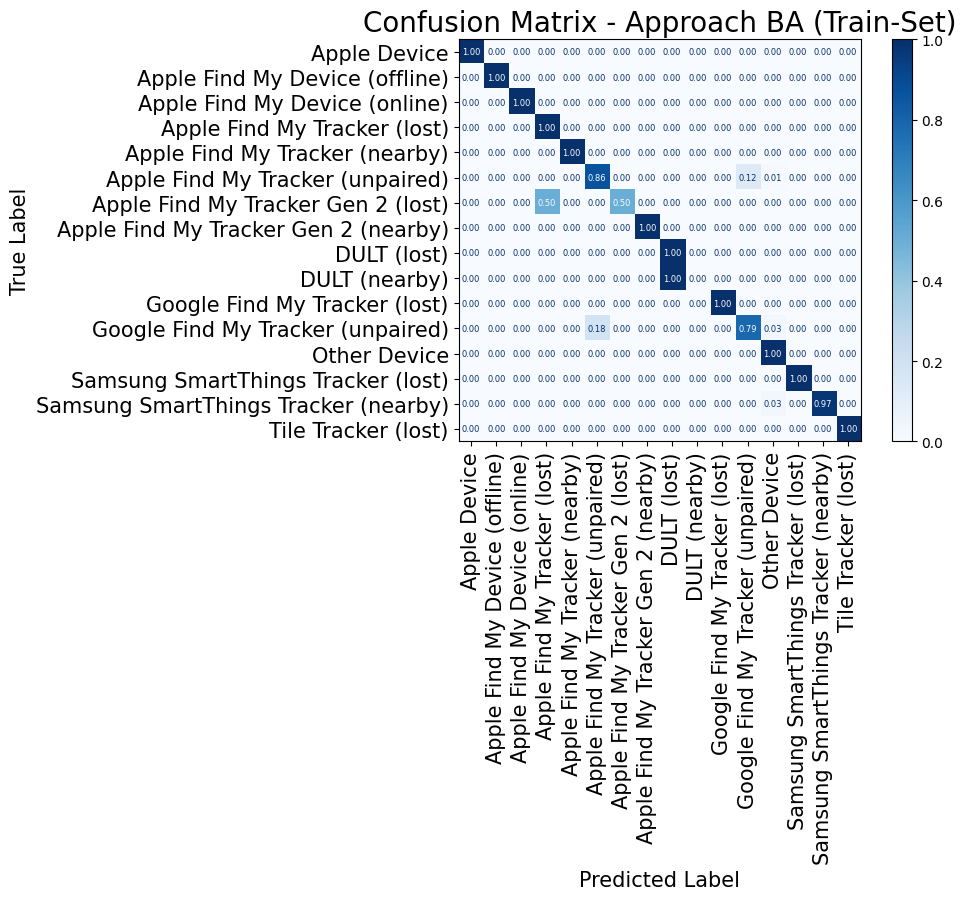

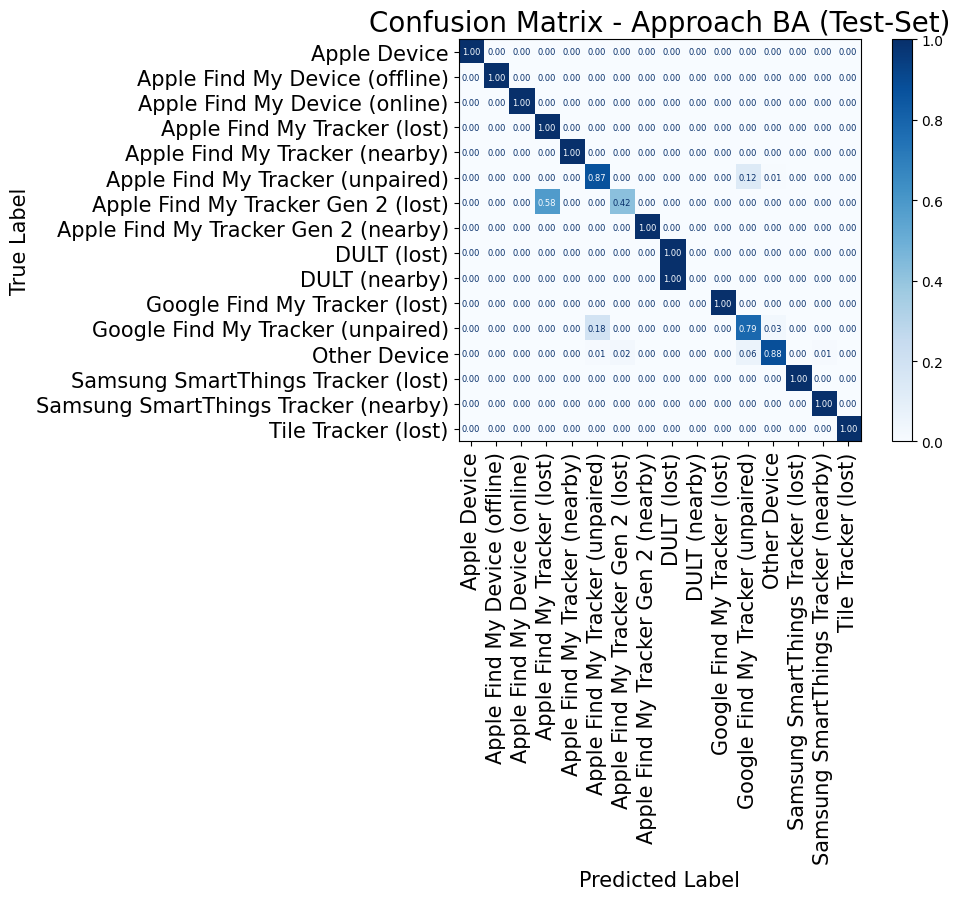


                                      precision    recall  f1-score   support

                        Apple Device     0.9756    1.0000    0.9877       200
      Apple Find My Device (offline)     0.9852    1.0000    0.9926       200
       Apple Find My Device (online)     0.9852    1.0000    0.9926       200
        Apple Find My Tracker (lost)     0.6329    1.0000    0.7752       200
      Apple Find My Tracker (nearby)     1.0000    1.0000    1.0000       200
    Apple Find My Tracker (unpaired)     0.7311    0.8700    0.7945       200
  Apple Find My Tracker Gen 2 (lost)     0.5385    0.4200    0.4719       200
Apple Find My Tracker Gen 2 (nearby)     0.9662    1.0000    0.9828       200
                         DULT (lost)     0.4975    1.0000    0.6645       200
                       DULT (nearby)     0.0000    0.0000    0.0000       200
       Google Find My Tracker (lost)     0.9479    1.0000    0.9732       200
   Google Find My Tracker (unpaired)     0.4337    0.7850    0

In [13]:
from plotting import plotMatrix, plotReport

preds = model.predict(x_train)
preds_text = [label_lut[i] for i in preds]
plotMatrix(y_train_text, preds_text, labels=sorted((list(set(labels_test)))), savePath=PlotPath, name = "Approach BA (Train-Set)")

preds = model.predict(x_test)
preds_text = [label_lut[i] for i in preds]
plotMatrix(y_test_text, preds_text, labels=sorted((list(set(labels_test)))), savePath=PlotPath, name = "Approach BA (Test-Set)")
plotReport(y_test_text, preds_text, labels=sorted((list(set(labels_test)))))

In [14]:
count = 0
correct= 0
for pred, y in zip(y_test, preds):
    count += 1
    if pred == y:
        correct += 1

print("Accuracy (micro): ", float(correct/count)*100, "%")

Accuracy (micro):  87.61666666666666 %


In [15]:
import numpy as np


probas = np.array(model.predict_proba(x_test))
pseudo_logits = np.log(np.clip(probas, 1e-15, 1.0))
pseudo_logits = torch.from_numpy(pseudo_logits)
targets = torch.from_numpy(np.array(y_test))

In [16]:
from evaluation_framework import Experiment, StaticMetricCollection, OSCRCurve, AccuracyOpenSet

PRECISION = 4

config = StaticMetricCollection([OSCRCurve(unknown_label=label_id_unknown, precision=PRECISION),
                                 AccuracyOpenSet(unknown_label=label_id_unknown, precision=PRECISION, average='macro'),]
                                )

exp = Experiment(name="Test-Experiment")


exp.configure(config)
exp.add_data(logits=pseudo_logits, targets=targets)

score = exp.score()


OSCR Curve started computing...
OSCR Curve finished computing in 0.03 minutes.
Accuracy Open Set (macro) started computing...
Accuracy Open Set (macro) finished computing in 0.00 minutes.


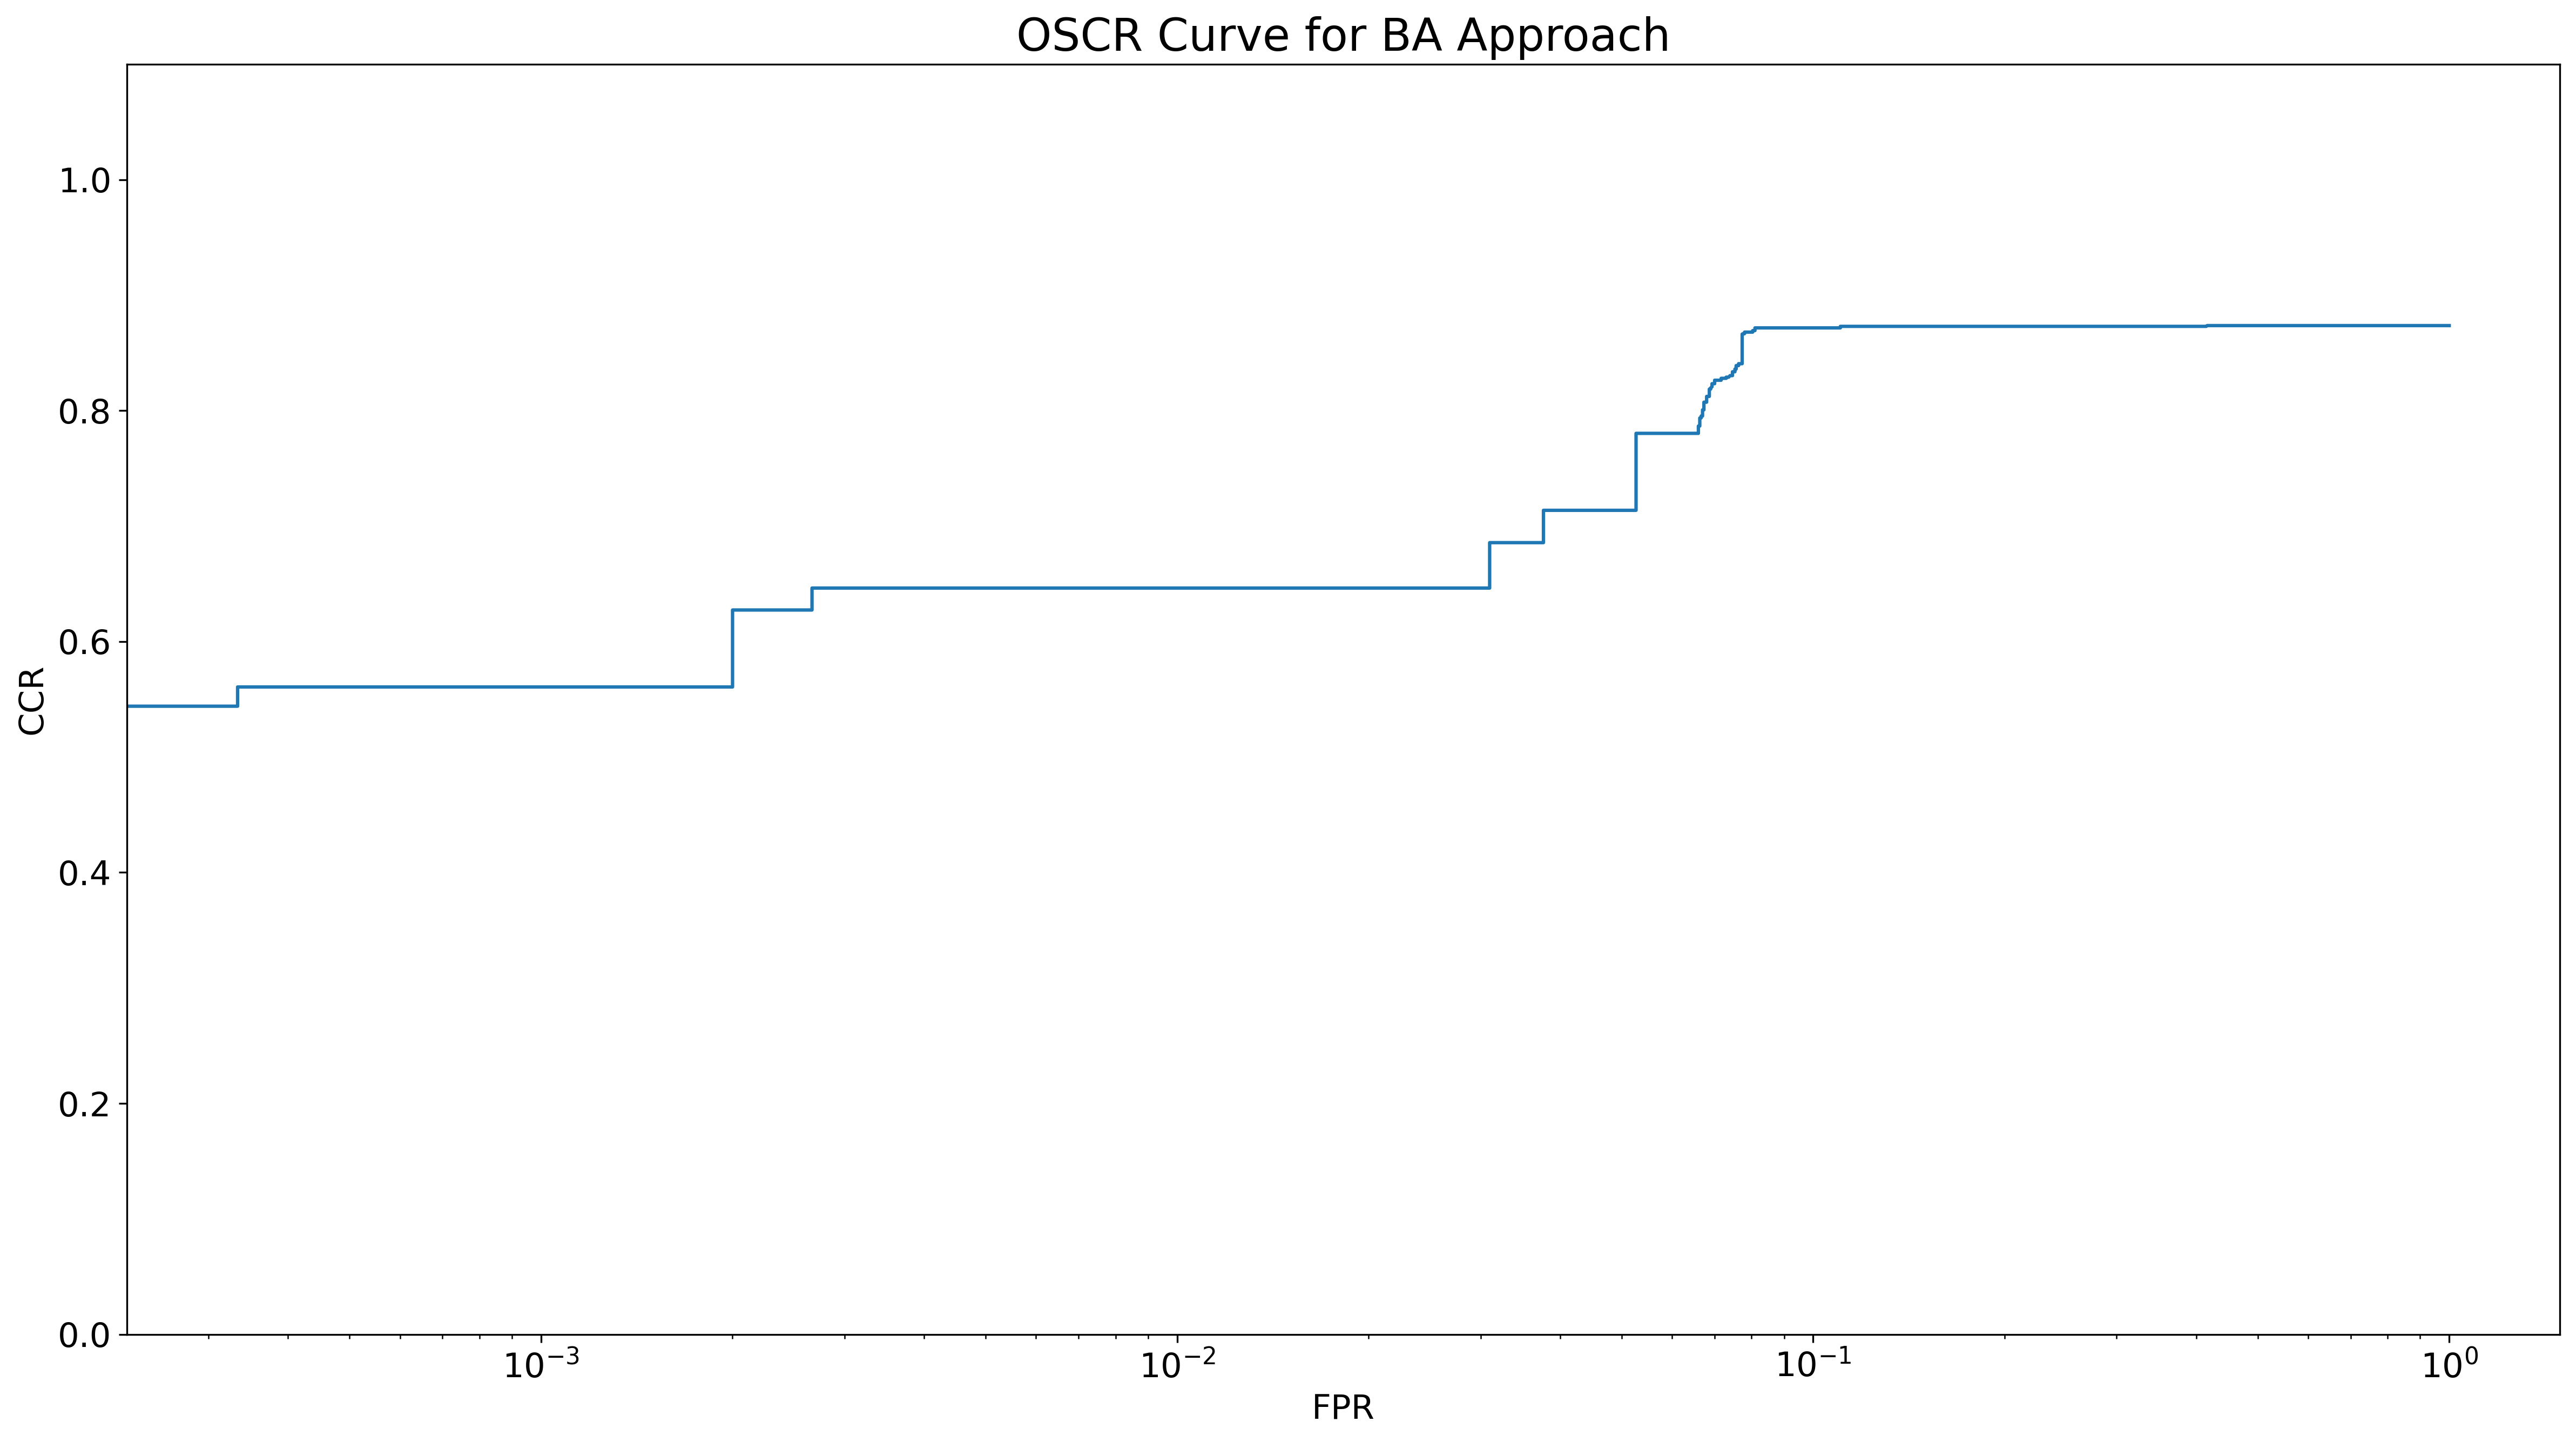

In [17]:
from matplotlib import pyplot as plt
from plotting.src.functions import plotMatrix, FONTSIZE_LABEL, FONTSIZE_TICKS, FONTSIZE_TITLE, plotReport

plt.figure(figsize=(16, 9), dpi = 300)

fprs = score['OSCR Curve'][:, 0]
ccrs = score['OSCR Curve'][:, 1]

plt.plot(fprs, ccrs)

plt.xticks(fontsize=FONTSIZE_TICKS)
plt.yticks(fontsize=FONTSIZE_TICKS)
plt.xlabel("Threshold", fontsize=FONTSIZE_LABEL)
plt.ylim(0, 1.1)
plt.xscale("log")
plt.ylabel("CCR", fontsize=FONTSIZE_LABEL)
plt.xlabel("FPR", fontsize=FONTSIZE_LABEL)
title = "OSCR Curve for BA Approach"
plt.title(title, fontsize=FONTSIZE_TITLE)
plt.tight_layout()
plt.savefig(PlotPath + title + ".png", dpi = 300)
plt.show()

In [18]:
fpr_01_idx = torch.argmin(torch.abs(0.1 - fprs))
fpr_001_idx = torch.argmin(torch.abs(0.01 - fprs))
fpr_0001_idx = torch.argmin(torch.abs(0.001 - fprs))

In [19]:
print("FPR 1e-1:", ccrs[fpr_01_idx])
print("FPR 1e-2:",  ccrs[fpr_001_idx])
print("FPR 1e-3:",  ccrs[fpr_0001_idx])

FPR 1e-1: tensor(0.8717)
FPR 1e-2: tensor(0.6463)
FPR 1e-3: tensor(0.5607)


In [20]:
picklePath = str(Path.cwd()) + r"\out\pickle_objects\modeling_ba" + "\\"

with open(picklePath +"ccrs" + '.pickle', 'wb') as f:
    pickle.dump(list(ccrs), f)

with open(picklePath +"fprs" + '.pickle', 'wb') as f:
    pickle.dump(list(fprs), f)

In [21]:
picklePathBA = str(Path.cwd()) + r"\out\pickle_objects\modeling_ba" + "\\"

In [22]:
with open(picklePathBA + "ccrs" + '.pickle', 'rb') as f:
    ccrs_ba = pickle.load(f)

with open(picklePathBA +"fprs" + '.pickle', 'rb') as f:
    fprs_ba = pickle.load(f)